In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import legend

plt.style.use('tableau-colorblind10')
sns.set_palette('colorblind')


In [2]:
df=pd.read_csv(r"../data/hour.csv")

# About the Dataset
## Backgroud
[**ToDo**]

## Features and Explanation
|Feature| Explanation|
|---|---|
|instant| record index |
|dteday| date |
|season| season <br> 1: spring <br> 2: summer <br> 3: fall<br> 4: winter) |
|yr| year <br> 0: 2011 <br> 1: 2012) |
|mnth| month (1 to 12) |
|hr| hour (0 to 23)  |
|holiday| weather the day is a holiday (1) or not (0) according to [http://dchr.dc.gov/page/holiday-schedule](http://dchr.dc.gov/page/holiday-schedule)|
|weekday| day of the week|
|workingday| weather the day is a workingday (1) or weekend/holiday (0) |
|weathersit| weathersituation <br> 1: Clear, few clouds, partly cloudy <br> 2: Mist + Cloudy, Mist + Broken Clouds, Mist + Few Clouds, Mist <br> 3: Light snow, Light rain + Thunderstorm + Scattered clouds, Light rain + Scatterd clouds <br> 4: Heavy rain + ice pallets + thunderstom + mist, Snow + fog |
|temp| normalized temperature in celcius. values are divided to 41 (max) |
|atemp|normalized feeling temperature in celcius. values are divide to 50 (max)|
|hum|normalized humidity. values are divided to 100 (max)|
|windspeed|normalized windspeed. values are divided to 67 (max) |
|casual|count of casual users|
|registered| count of registered users|
|cnt|count of total users|

In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df.shape

(17379, 17)

In [5]:
df["dteday"]=df["dteday"].astype("datetime64[ns]")

In [6]:
df.dtypes

instant                int64
dteday        datetime64[ns]
season                 int64
yr                     int64
mnth                   int64
hr                     int64
holiday                int64
weekday                int64
workingday             int64
weathersit             int64
temp                 float64
atemp                float64
hum                  float64
windspeed            float64
casual                 int64
registered             int64
cnt                    int64
dtype: object

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-null  int64

In [8]:
X=df.drop(columns=["instant","cnt"])

In [9]:
X.head(5)

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1


In [10]:
y=df["cnt"]

In [11]:
y.head(5)

0    16
1    40
2    32
3    13
4     1
Name: cnt, dtype: int64

<Axes: >

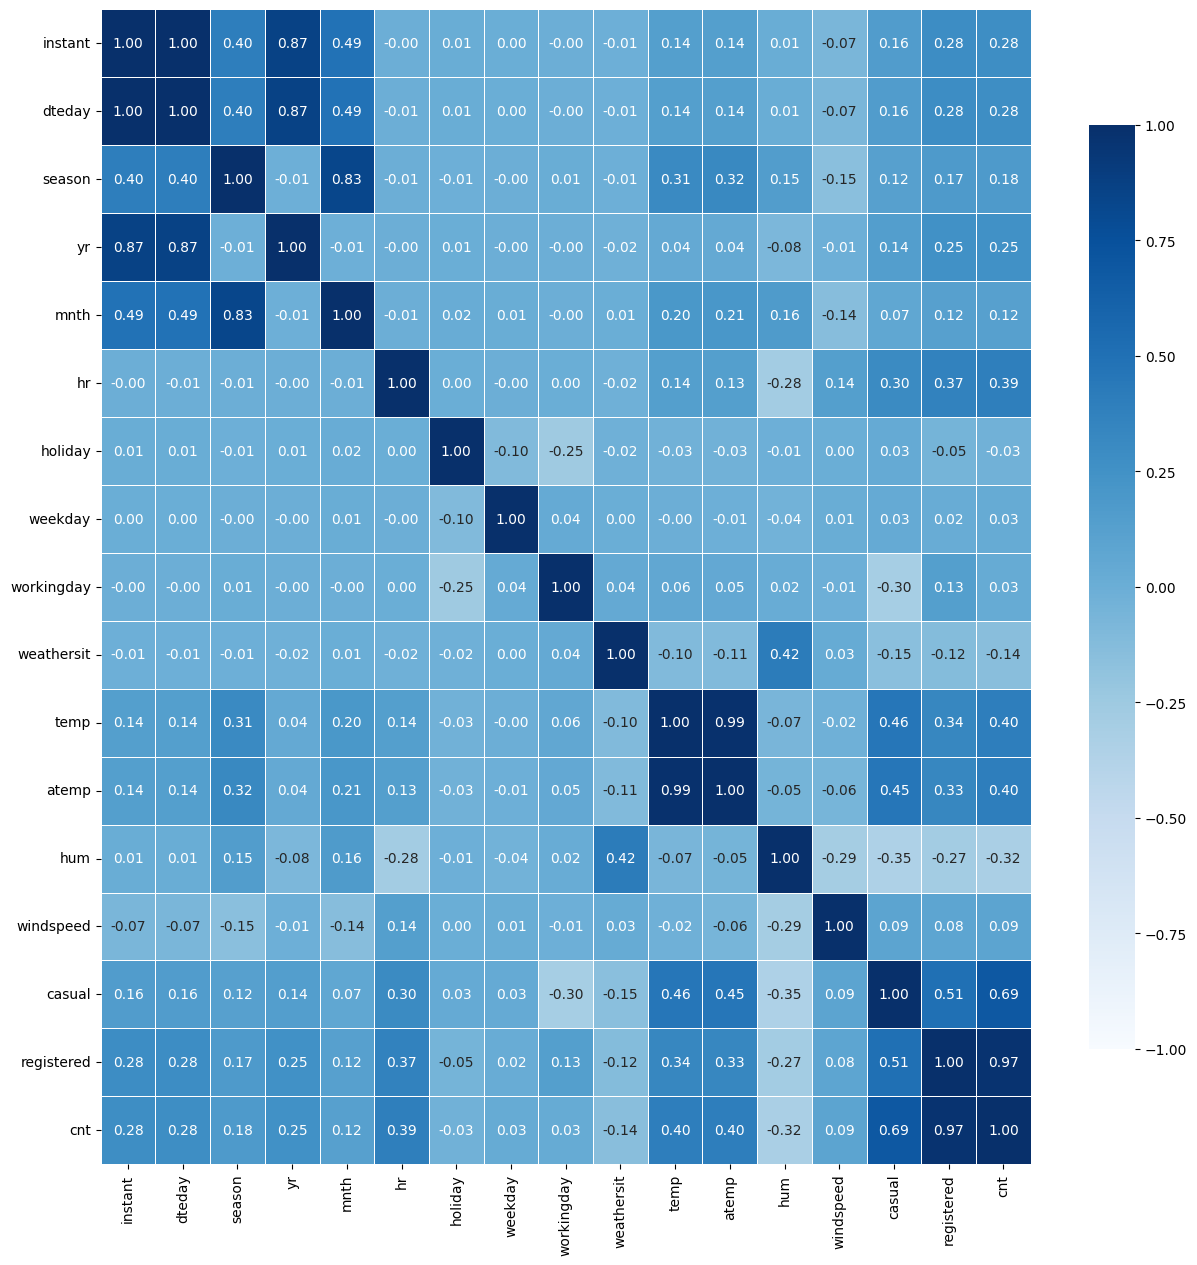

In [12]:
corr_matrix=df.corr()
plt.figure(figsize=(15,15))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    cbar_kws={'shrink': .8}
)

Text(0.5, 1.0, 'Count per Season')

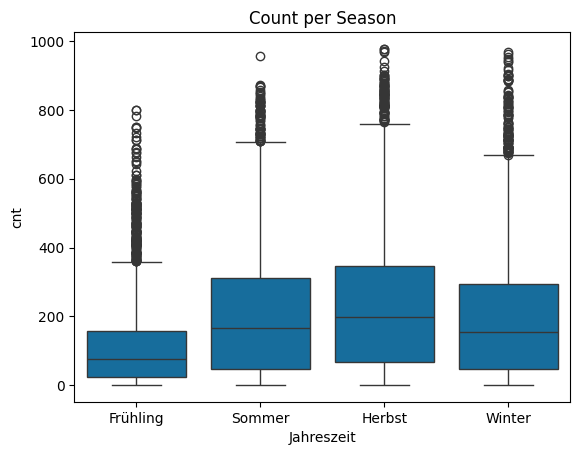

In [13]:
season_map = {1: 'Frühling', 2: 'Sommer', 3: 'Herbst', 4: 'Winter'}
df['Jahreszeit'] = df['season'].map(season_map)
#plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='Jahreszeit', y='cnt', order=['Frühling', 'Sommer', 'Herbst', 'Winter'])
plt.title("Count per Season")

Text(0.5, 1.0, 'Count at Weather')

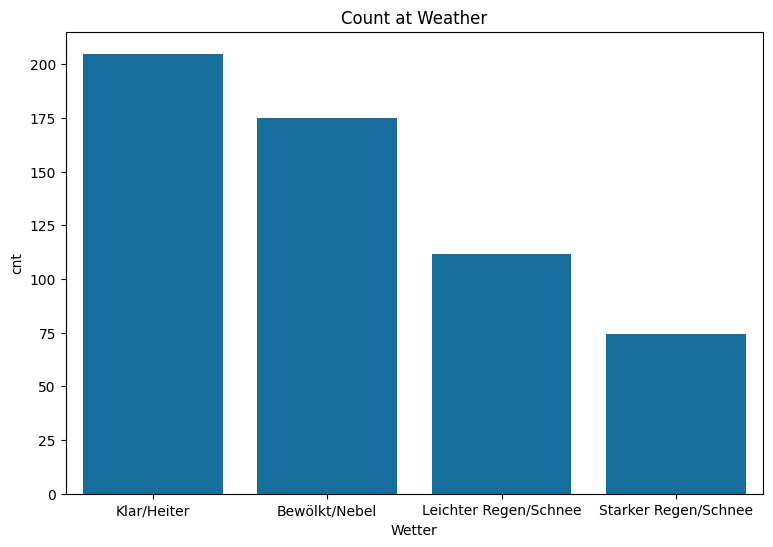

In [14]:
weather_map = {1: 'Klar/Heiter', 2: 'Bewölkt/Nebel', 3: 'Leichter Regen/Schnee', 4: 'Starker Regen/Schnee'}
df['Wetter'] = df['weathersit'].map(weather_map)
plt.figure(figsize=(9,6))
sns.barplot(data=df, x='Wetter', y='cnt', errorbar=None,)
plt.title("Count at Weather")

Text(0.5, 1.0, 'Count per Daykind')

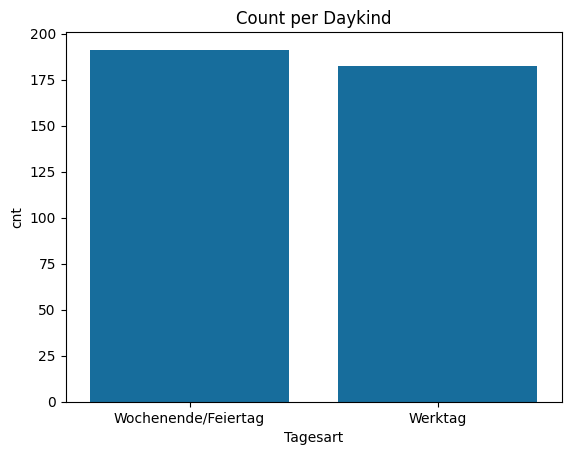

In [15]:
workingday_map = {0: 'Wochenende/Feiertag', 1: 'Werktag'}
df_sample = df.sample(frac=0.05, random_state=42)
df_sample['Tagesart'] = df_sample['workingday'].map(workingday_map)
sns.barplot(data=df_sample, x='Tagesart', y='cnt', errorbar=None,)
plt.title("Count per Daykind")

In [16]:
df_sample

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,Jahreszeit,Wetter,Tagesart
12830,12831,2012-06-23,3,1,6,19,0,6,0,1,0.80,0.6970,0.27,0.1940,185,240,425,Herbst,Klar/Heiter,Wochenende/Feiertag
8688,8689,2012-01-02,1,1,1,20,1,1,0,1,0.24,0.2273,0.41,0.2239,5,83,88,Frühling,Klar/Heiter,Wochenende/Feiertag
7091,7092,2011-10-28,4,0,10,2,0,5,1,1,0.32,0.3030,0.66,0.2836,1,3,4,Winter,Klar/Heiter,Werktag
12230,12231,2012-05-29,2,1,5,19,0,2,1,1,0.78,0.7121,0.52,0.3582,69,457,526,Sommer,Klar/Heiter,Werktag
431,432,2011-01-20,1,0,1,0,0,4,1,1,0.26,0.2273,0.56,0.3881,5,8,13,Frühling,Klar/Heiter,Werktag
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5446,5447,2011-08-19,3,0,8,20,0,5,1,3,0.62,0.5758,0.83,0.2985,12,46,58,Herbst,Leichter Regen/Schnee,Werktag
3433,3434,2011-05-27,2,0,5,23,0,5,1,1,0.58,0.5455,0.88,0.1343,23,104,127,Sommer,Klar/Heiter,Werktag
16854,16855,2012-12-10,4,1,12,1,0,1,1,2,0.36,0.3788,1.00,0.0000,0,4,4,Winter,Bewölkt/Nebel,Werktag
6951,6952,2011-10-22,4,0,10,6,0,6,0,1,0.36,0.3788,0.71,0.0000,1,17,18,Winter,Klar/Heiter,Wochenende/Feiertag


Text(0.5, 1.0, 'Count per Month')

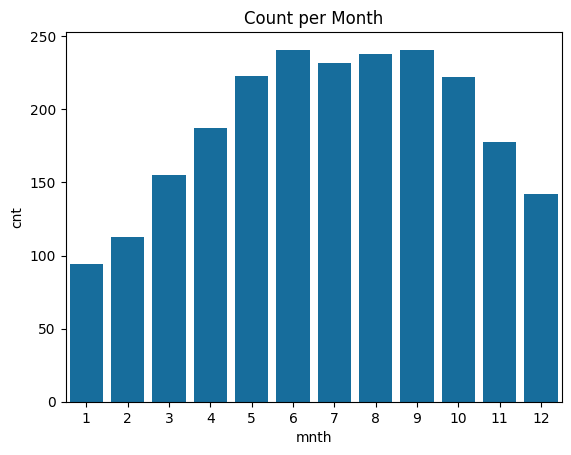

In [29]:
sns.barplot(
    data=df,
    x='mnth',
    y='cnt',
    errorbar=None,
    )
plt.title("Count per Month")

<Axes: xlabel='hr', ylabel='temp'>

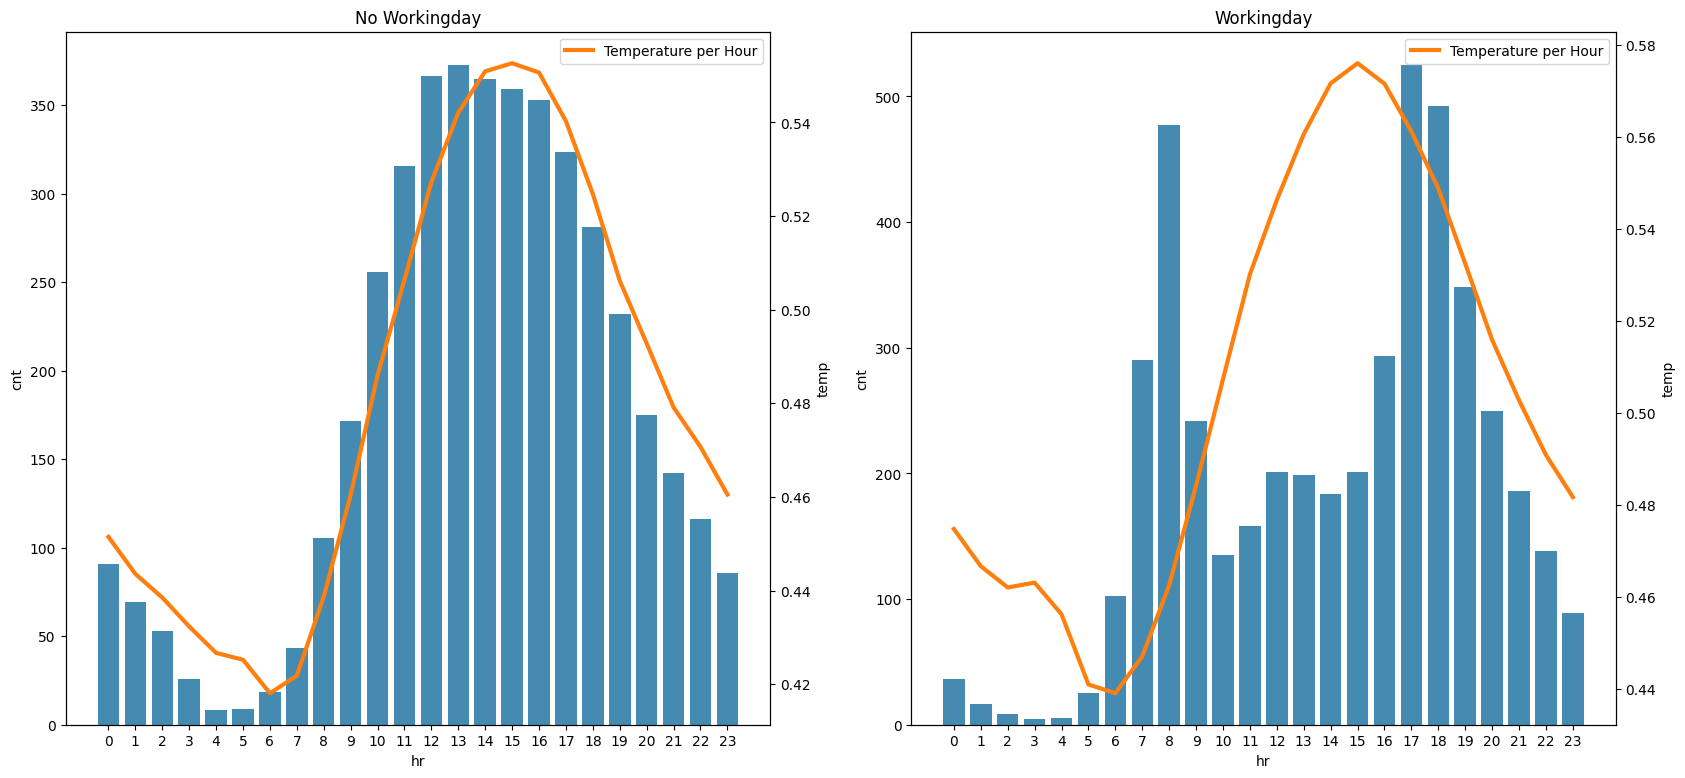

In [40]:
fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(20, 9))
sns.barplot(
    data=df[df["workingday"]==0],
    x='hr',
    y='cnt',
    alpha=0.8,
    errorbar=None,
    ax=ax1,
)
plt.title("Workingday")
ax2=ax1.twinx()
sns.lineplot(
    data=df[df["workingday"]==0],
    x='hr',
    y='temp',
    color='#ff7f0e',
    errorbar=None,
    ax=ax2,
    linewidth=3,
    label='Temperature per Hour'
)
sns.barplot(
    data=df[df["workingday"]==1],
    x='hr',
    y='cnt',
    alpha=0.8,
    errorbar=None,
    ax=ax3,
)
plt.title("No Workingday")
ax4=ax3.twinx()
sns.lineplot(
    data=df[df["workingday"]==1],
    x='hr',
    y='temp',
    color='#ff7f0e',
    errorbar=None,
    ax=ax4,
    linewidth=3,
    label='Temperature per Hour'
)

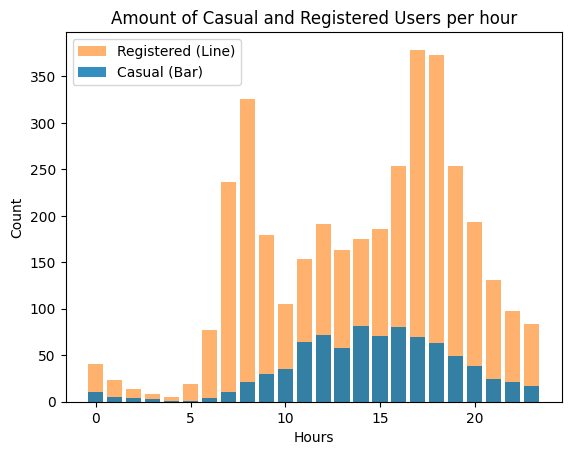

In [28]:
data_to_plot = df_sample.groupby('hr')[['casual', 'registered']].mean()
plt.bar(data_to_plot.index, data_to_plot['registered'], color='#ff7f0e', label='Registered', alpha=0.6)
plt.bar(data_to_plot.index, data_to_plot['casual'], label='Casual', alpha=0.8)
plt.xlabel("Hours")
plt.ylabel("Count")
plt.title("Amount of Casual and Registered Users per hour")
plt.legend()
plt.show()